# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Messy Data for Cleaning

In [2]:
df = pd.read_csv('ParkData.csv')

# Drop empty columns (extra column at the end)
df = df.dropna(axis = 1, how = 'all')

# Drop rows where Year or Month are missing (extra rows at the end)
df = df.dropna(subset = ['Year', 'Month'])

df.shape # Should get 552 rows and 14 columns

(552, 14)

In [3]:
# Function to remove commas in numbers
def clean_number(value):
    if pd.isna(value):
        return 0
    if (type(value) == str):
        # Remove commas
        clean_val = value.replace(',', '').strip()
        try:
            return clean_val
        except ValueError:
            return 0
    return value

# Apply function to all numeric columns
numeric_cols = [
    'Recreation Visitors',
    'Non-Recreation Visitors',
    'Recreation Visitor Hours',
    'Non-Recreation Hours',
    'Concession Lodging',
    'Tent Campers',
    'RV Campers',
    'Concession Camping',
    'Backcountry Campers',
    'Misc Campers',
    'Non-Recreation Overnight Stays',
    'Total Overnight Stays'
]

for col in numeric_cols:
    df[col] = df[col].apply(clean_number).astype(int)

In [4]:
# Convert Year and Month to Date Column
# Create dictionary to map month names to numbers
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

# Create date column
df['Month_Num'] = df['Month'].map(month_map)
df['Year'] = df['Year'].astype(int) # makes Year column into integer instead of float

df['Date'] = pd.to_datetime(pd.DataFrame({
    'year': df['Year'],
    'month': df['Month_Num'],
    'day': 1
}))

# Save clean version 
df.to_csv('Cleaned_ParkData.csv', index = False)

# Exploratory Data Analysis (EDA)

### Initial EDA (Full Dataset)

In [5]:
# Check data types and missing values after cleaning
print('Number of Missing Values per Column:')
print(df.isnull().sum())

# Summary statistics for numeric columns
print('\nSummary Statistics:')
display(df.drop(columns = ['Year', 'Month', 'Month_Num', 'Date']).describe())

Number of Missing Values per Column:
Year                              0
Month                             0
Recreation Visitors               0
Non-Recreation Visitors           0
Recreation Visitor Hours          0
Non-Recreation Hours              0
Concession Lodging                0
Tent Campers                      0
RV Campers                        0
Concession Camping                0
Backcountry Campers               0
Misc Campers                      0
Non-Recreation Overnight Stays    0
Total Overnight Stays             0
Month_Num                         0
Date                              0
dtype: int64

Summary Statistics:


,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays
count,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.0,552.000000,552.000000,552.000000,552.000000,552.000000
mean,1692.844203,20.820652,110385.882246,1487.293478,639.693841,564.331522,0.0,64.298913,2841.583333,391.347826,61.581522,4562.836957
std,2635.870738,110.543561,171092.449471,2282.068775,1127.900159,1076.173733,0.0,161.672641,4384.047489,873.213833,94.948513,7025.329337
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,41.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,193.500000,2.000000,1082.500000,144.000000,0.000000,0.000000,0.0,0.000000,14.000000,0.000000,4.500000,100.000000
75%,2495.750000,17.000000,175379.250000,2208.000000,952.250000,860.250000,0.0,39.000000,4375.250000,348.750000,91.000000,7348.000000
max,10861.000000,1814.000000,683855.000000,14748.000000,4895.000000,12695.000000,0.0,1291.000000,17635.000000,7195.000000,614.000000,27741.000000


The first table confirms that there are no missing values across all 16 columns. 

The summary statistics indicate that visitation data is highly right-skewed. The *Recreation Visitors* mean (1692.84) is significantly greater than the median (193.50). This confirms that visitation data is primarily influenced by seasonal closure and extreme highs during summer travel season. The summary statistics also show that every value in the *RV Campers* columns is 0, which acts as a successful data validaton since Isle Royale is only accessible by boat or seaplane. Looking at the averages across our 46-year range, we see that *Backcountry Campers* greatly outnumber *Concession Lodging*, which shows that infrastructure demand for the park is providing wilderness adventure and not traditional hospitality services.

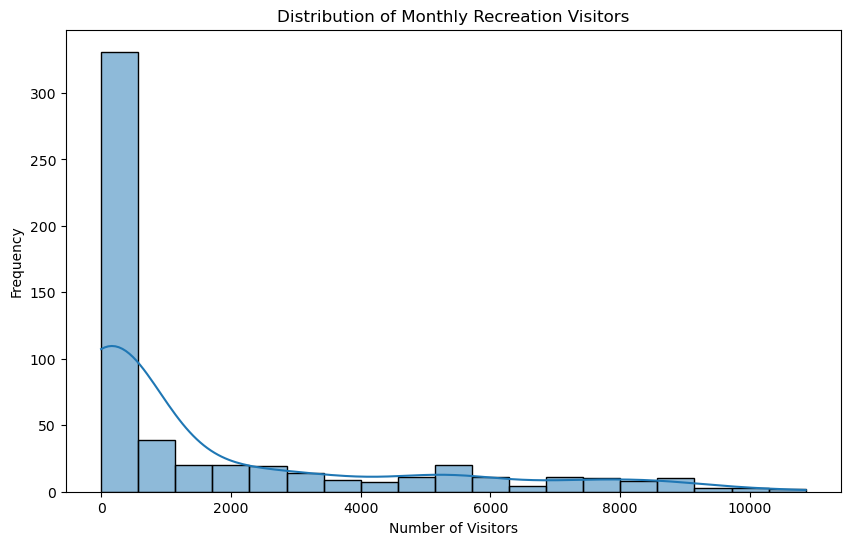

In [6]:
# Distribution of Recreation Visitors
plt.figure(figsize = (10, 6))

sns.histplot(df['Recreation Visitors'], kde = True)

plt.title('Distribution of Monthly Recreation Visitors')
plt.xlabel('Number of Visitors')
plt.ylabel('Frequency')
plt.show()

The distribution of monthly recreation visitors reveals the data is heavily right-skewed.

- Because the park is closed to the public for about half the year, most of the frequent monthly visitor count is zero.
- The long right tail of the graph indicates the high-intensity summer months, so while the values are significantly higher than the annual mean, they represent the park's full operational capacity instead of random anomalies.

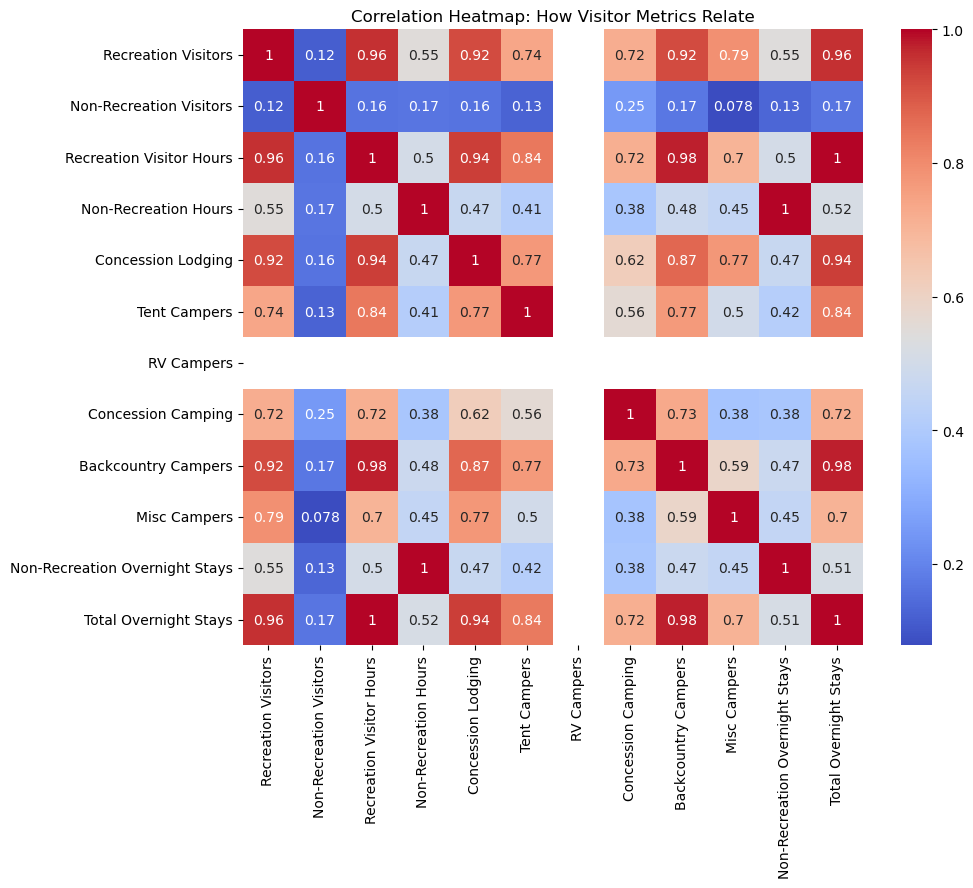

In [7]:
# Correlation heatmap to see relationships between different visitor types
plt.figure(figsize = (10, 8))

corr_matrix = df.drop(columns = ['Year', 'Month', 'Month_Num', 'Date']).corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')

plt.title('Correlation Heatmap: How Visitor Metrics Relate')
plt.show()

The correlation heatmap above helps us to better determine which park services are used together with others and which ones operate independently. 

- **Primary Drivers of Visitation:** The 3 main drivers of visitation that have a correlation > 0.95 are *Recreation Visitors*, *Recreation Visitor Hours*, and *Total Overnight Stays*. This means that as visitation increases, the duration of stays remain consistent, suggesting that visitors stay on Isle Royale for longer periods of time instead of just quickly stopping by.
  
- **Wilderness vs. Intrastructure:** Both *Backcountry Campers* and *Tent Campers* have high correlations with total recreation visitors, which indicate that the park's growth heavily depends on wilderness infrastructure like trails and campsites.

- **Independent Metrics:** *Non-Recreation Visitors* have very low correlations with almost all other categories, which could mean that adminisitrative, research, or non-tourist activities remain steady year-round regardless, of whether the park is in its "peak" tourist month.

<Figure size 1200x600 with 0 Axes>

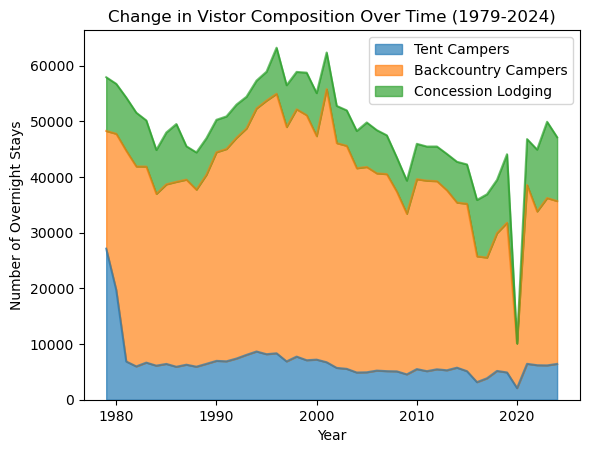

In [8]:
# Grouping by year and looking at proportion of different camper types
plt.figure(figsize = (12, 6))

composition_data = df.groupby('Year')[['Tent Campers', 'Backcountry Campers', 'Concession Lodging']].sum()
composition_data.plot(kind = 'area', stacked = True, alpha = 0.67)

plt.title('Change in Vistor Composition Over Time (1979-2024)')
plt.ylabel('Number of Overnight Stays')
plt.legend(loc = 'upper right')
plt.show()

The chart above confirms that *Backcountry Camping* has remained the dominant mode of overnight stay on Isle Royale from 1979 to 2024. While *Concession Lodging* shows a relatively fixed and stable capacity, the *Backcountry* and *Tent Camping* categories exhibit higher volatility, absorbing the vast majority of the park's visitation surges over the decades.

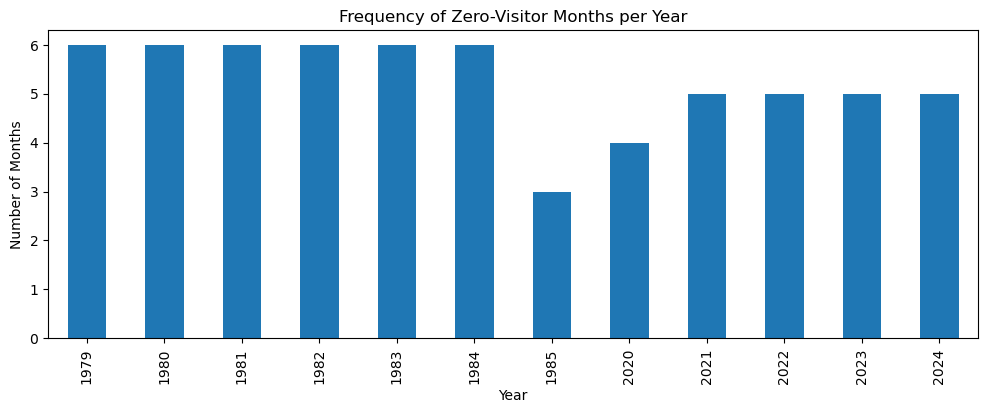

In [9]:
# Counting months with zero visitors per year
plt.figure(figsize = (12, 4))

zero_months = df[df['Recreation Visitors'] == 0].groupby('Year').size()
zero_months.plot(kind = 'bar')

plt.title('Frequency of Zero-Visitor Months per Year')
plt.ylabel('Number of Months')
plt.show()

The frequency of zero-visitor months provides a unique look at the park's operational boundaries. While a 5.5-month closure was the standard for the first 25 years of the dataset, we observe a significant shift in the last few years (2020–2024), where zero-visitor months have dropped to 4 or 5. This suggests an expansion of the 'active' season, likely due to shoulder-season maintenance or climate-related changes allowing for earlier/later access. Additionally, the anomaly in 1985 (only 3 months of zero visitors) marks a period of high off-season activity that warrants further historical investigation.

### Seasonality Problem

We observed that the almost 6-month winter closure creates a heavy right-skew, as well as possible artificial correlations. In order to more accurately explore the data, we will take a subset of just the months that Isle Royale is open for each year.

In [10]:
# Creating subset of operating months (April 16-October 31)
df_open = df[(df['Month_Num'] >= 4) & (df['Month_Num'] <= 10)].copy()
df_open.to_csv('Open_Season_ParkData.csv', index = False)

### Refined EDA (Subset of Operating Months)

In [11]:
# Check data types and missing values for operating season
print('Number of Missing Values per Column for Operating Season:')
print(df_open.isnull().sum())

# Summary statistics for numeric columns for operating season
print('\nSummary Statistics for Operating Season:')
display(df_open.drop(columns = ['Year', 'Month', 'Month_Num', 'Date']).describe())

Number of Missing Values per Column for Operating Season:
Year                              0
Month                             0
Recreation Visitors               0
Non-Recreation Visitors           0
Recreation Visitor Hours          0
Non-Recreation Hours              0
Concession Lodging                0
Tent Campers                      0
RV Campers                        0
Concession Camping                0
Backcountry Campers               0
Misc Campers                      0
Non-Recreation Overnight Stays    0
Total Overnight Stays             0
Month_Num                         0
Date                              0
dtype: int64

Summary Statistics for Operating Season:


,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.0,322.000000,322.000000,322.000000,322.000000,322.000000
mean,2859.819876,34.245342,189161.891304,2375.257764,1096.618012,967.425466,0.0,110.226708,4871.285714,670.881988,98.335404,7814.773292
std,2939.488903,143.059642,187900.896988,2552.559037,1296.550095,1263.645025,0.0,199.469284,4803.442397,1058.643012,106.348891,7697.962995
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,253.500000,2.000000,9142.500000,273.000000,0.000000,49.500000,0.0,0.000000,233.500000,31.000000,10.000000,429.500000
50%,1806.500000,11.500000,122827.500000,1540.000000,514.000000,662.500000,0.0,21.000000,3417.500000,243.000000,64.500000,5042.000000
75%,5160.250000,25.750000,370733.750000,3668.000000,2066.250000,1441.000000,0.0,127.750000,8648.500000,897.500000,152.250000,15090.250000
max,10861.000000,1814.000000,683855.000000,14748.000000,4895.000000,12695.000000,0.0,1291.000000,17635.000000,7195.000000,614.000000,27741.000000


The first table confirms that there are no missing values across all 16 columns for the operating season. 

The summary statistics indicate that operating season shrunk the sample size from 552 to 322 months. The *Recreation Visitors* median increased from 193.50 to 1806.50, which represents a more 'typical' month for use in resource management. While eliminating most of the zeros from the winter months has increased the median so it's closer to the mean, the mean is still much larger. This indicates that the peak season months skew the averages up, even when only considering the months that Isle Royale is actually open.

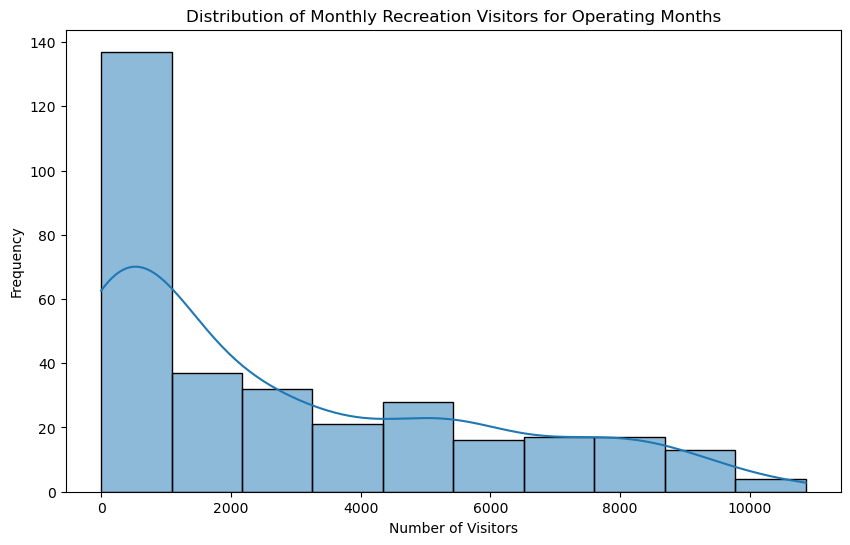

In [12]:
# Distribution of Recreation Visitors on operating months
plt.figure(figsize = (10, 6))

sns.histplot(df_open['Recreation Visitors'], kde = True)

plt.title('Distribution of Monthly Recreation Visitors for Operating Months')
plt.xlabel('Number of Visitors')
plt.ylabel('Frequency')
plt.show()

Through only using the months that Isle Royale is actually open, we removed the high frequencey of zero values caused by winter closures, which gives a better sense of the park's active capacity. We can also see that the most 'operational' months cluster between 0 and 2,000 visitors, probably during the months of April, May, and October when the weather is more unpredictable, with a smooth gradient down to the summer peak months. Even without the zeros from the months the park is closed, the data is still heavily reight-skewed.

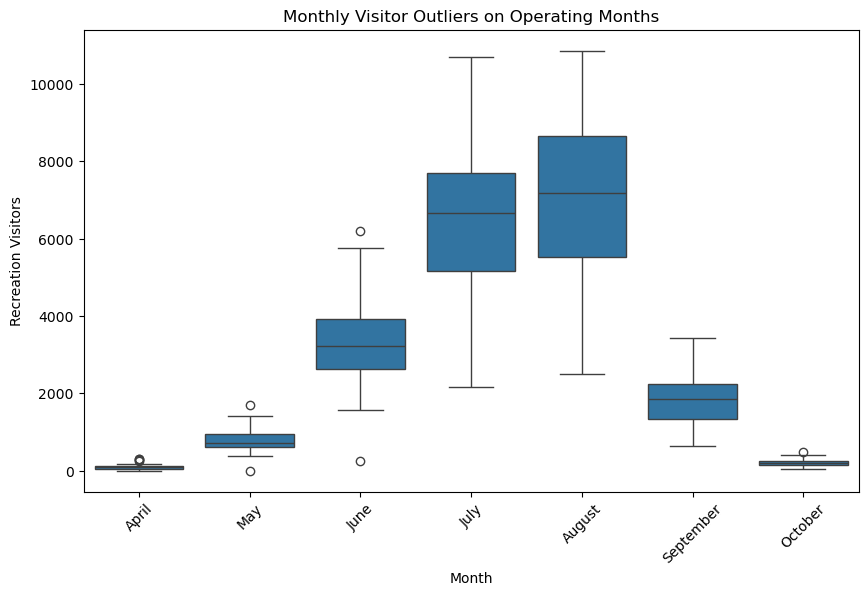

In [13]:
# Boxplot of monthly visitor outliers on subset
plt.figure(figsize = (10, 6))

sns.boxplot(x = 'Month', y = 'Recreation Visitors', data = df_open)

plt.title('Monthly Visitor Outliers on Operating Months')
plt.xticks(rotation = 45)
plt.show()

Based on the boxplots, August has the highest median count, which indicates it is the peak month for visitors. Augest also seems to have the widest IQR, which means that it contains the most variation in visitation from year-to-year. The tight distributions of April, May, and October have the lowest medians, which indicate that early- and late-season visitation hasn't changed much over the past 46 years. May, June, and October contain some outliers, which means those months had either high or low visitation compared to their normal ranges.

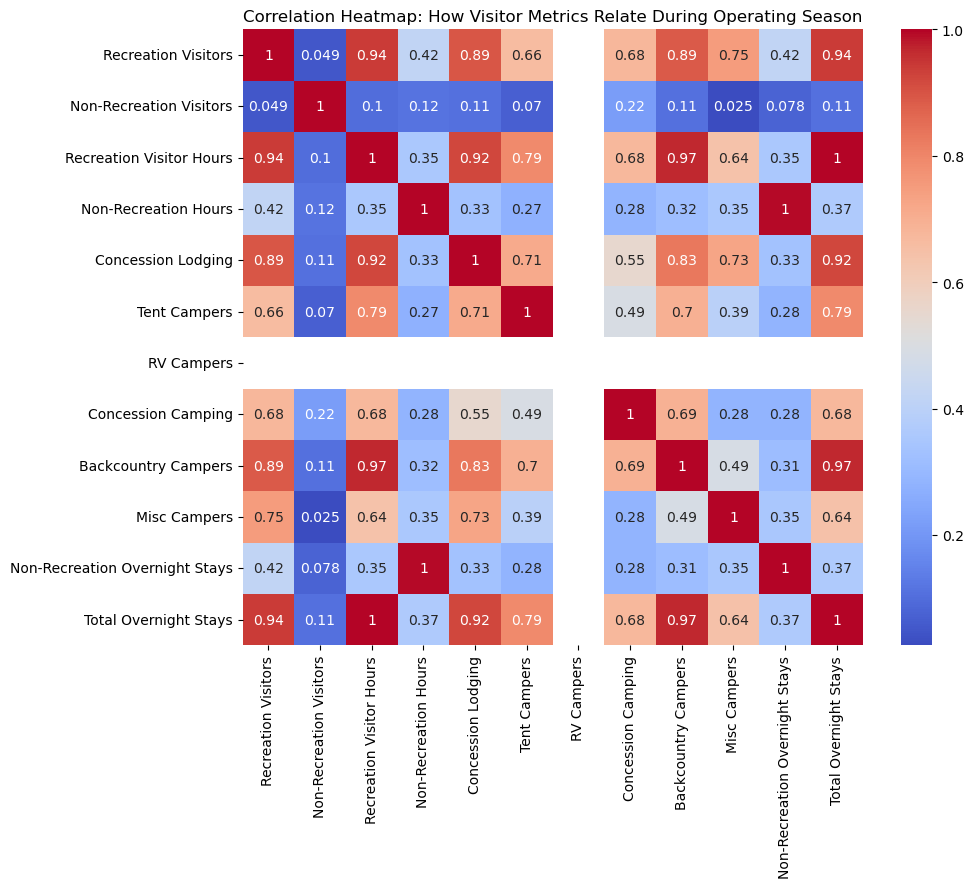

In [14]:
# Correlation heatmap to see relationships between different visitor types on operating months
plt.figure(figsize = (10, 8))

corr_matrix = df_open.drop(columns = ['Year', 'Month', 'Month_Num', 'Date']).corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')

plt.title('Correlation Heatmap: How Visitor Metrics Relate During Operating Season')
plt.show()

The correlation heatmap of the subset containing just the months that Isle Royale is open is shown above.

- **Primary Drivers of Visitation:** We still see that the 3 main drivers of visitation are *Recreation Visitors*, *Recreation Visitor Hours*, and *Total Overnight Stays*, but the correlations are just slightly less (0.94) from (0.96).
  
- **Wilderness vs. Infrastructure:** Both *Backcountry Campers* and *Tent Campers* still have pretty high correlations with total recreation visitors, but again, the correlations are slightly lower than using the full dataset.

- **Independent Metrics:** *Non-Recreation Visitors* correlations remain very low with almost all other categories.

The consistent decrease in correlations mean that the full dataset was overstating the impact each variable has over another, but that the subset reveals the true operational coupling during the active season.

# Analyzing Yearly/Monthly Visitation Stats

### Annual Visitation Analysis

In [15]:
# Calculate stats for full year
annual_full = df.groupby('Year')['Recreation Visitors'].agg([
    'min',
    'mean',
    'max',
    'sum'
]).reset_index()
annual_full.columns = [
    'Year',
    'Full_Min',
    'Full_Avg',
    'Full_Max',
    'Total_Annual'
]

print('Annual Stats for Full Year:')
print(annual_full.head(10))

# Calculate stats for open season 
annual_open = df_open.groupby('Year')['Recreation Visitors'].agg([
    'min',
    'mean',
    'max',
    'sum'
]).reset_index()
annual_open.columns = [
    'Year',
    'Open_Min',
    'Open_Avg',
    'Open_Max',
    'Open_Total_Annual'
]

print('Annual Stats for Operating Season:')
print(annual_open.head(10))

# Merge tables for comparison
annual_comparison = pd.merge(annual_full, annual_open, on = 'Year')

print('Annual Comparison:')
print(annual_comparison[[
    'Year',
    'Full_Min',
    'Open_Min',
    'Full_Avg',
    'Open_Avg',
    'Full_Max',
    'Total_Annual'
]].head(10))

Annual Stats for Full Year:
   Year  Full_Min     Full_Avg  Full_Max  Total_Annual
0  1979         0  1231.833333      5713         14782
1  1980         0  1248.083333      5934         14977
2  1981         0  1213.166667      5265         14558
3  1982         0  1103.166667      5012         13238
4  1983         0  1077.333333      4953         12928
5  1984         0   984.500000      4748         11814
6  1985         0  1397.916667      6050         16775
7  1986        22  2176.833333      9583         26122
8  1987        25  2646.666667     10861         31760
9  1988        12  2216.083333      9471         26593
Annual Stats for Operating Season:
   Year  Open_Min     Open_Avg  Open_Max  Open_Total_Annual
0  1979         0  2111.714286      5713              14782
1  1980         0  2139.571429      5934              14977
2  1981         0  2079.714286      5265              14558
3  1982         0  1891.142857      5012              13238
4  1983         0  1846.857143  

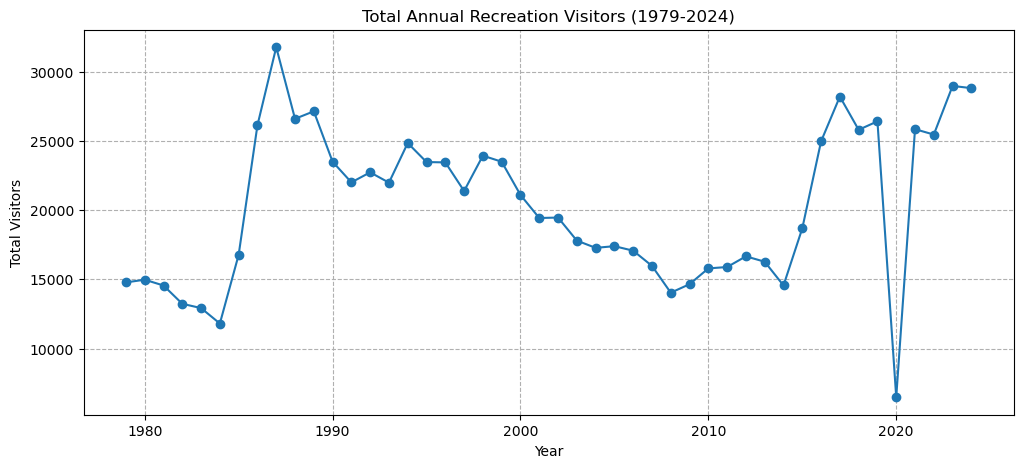

In [16]:
# Visualization of anuual visitation
plt.figure(figsize = (12, 5))

plt.plot(annual_comparison['Year'], annual_comparison['Total_Annual'], marker = 'o')

plt.title('Total Annual Recreation Visitors (1979-2024)')
plt.xlabel('Year')
plt.ylabel('Total Visitors')
plt.grid(True, linestyle = '--')
plt.show()

The graph above shows whether the park is becoming more popular over the decades. Based on the graph, Isle Royale was most popular in 1987 but had a gradual decline until 2014, where it had an increase to almost 30,000 visitors per year in recent years. There was a huge decline that occurred in 2020 when the COVID-19 pandemic first started.

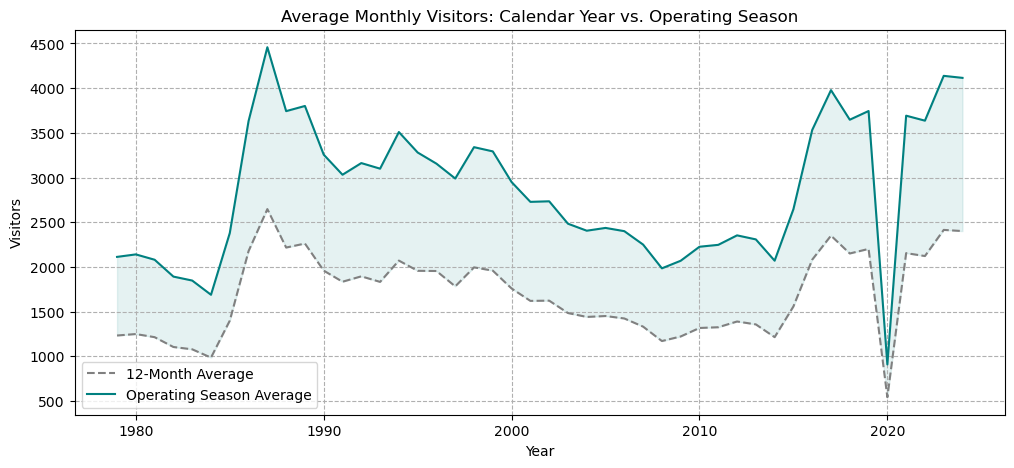

In [17]:
# Visualization of full year average vs. operating average (shows seasonality gap)
plt.figure(figsize = (12, 5))

plt.plot(annual_comparison['Year'], annual_comparison['Full_Avg'], label = '12-Month Average', color = 'gray', linestyle = '--')
plt.plot(annual_comparison['Year'], annual_comparison['Open_Avg'], label = 'Operating Season Average', color = 'teal')
plt.fill_between(annual_comparison['Year'], annual_comparison['Full_Avg'], annual_comparison['Open_Avg'], color = 'teal', alpha = 0.1)

plt.title('Average Monthly Visitors: Calendar Year vs. Operating Season')
plt.xlabel('Year')
plt.ylabel('Visitors')
plt.legend()
plt.grid(True, linestyle = '--')
plt.show()

The graph above explains the intensity of work on Isle Royale. The teal line represents the average number of visitors per month only when the park is open (mid-April - October). The dashed gray line represents the average visitors spread across all 12 months. The shaded seasonality gap is the hidden pressure of the seasonal park. If you only look at the 12-month average gray line, you underestimate the park's operational needs by almost 50%. 

### Monthly Visitation Analysis (Based on All Years)

In [18]:
# Defining order for plotting
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

# Monthly stats for full year
monthly_stats = df.groupby('Month')['Recreation Visitors'].agg([
    'min',
    'max',
    'mean'
]).reindex(month_order)

print('Historical Monthly Extremes:')
print(monthly_stats)

Historical Monthly Extremes:
            min    max         mean
Month                              
January       0     78    29.369565
February      0    116    38.217391
March         0    419    79.000000
April         0    300    93.369565
May           0   1689   792.282609
June        240   6184  3358.956522
July       2160  10702  6527.326087
August     2494  10861  7157.500000
September   640   3421  1892.956522
October      32    474   196.347826
November      0    154    31.086957
December      0   1058   117.717391


In [19]:
# add visualization

#### Monthly Visitation Analysis Per Year

In [20]:
# Monthly visitation analysis per year
yearly_monthly_stats = df.groupby([
    'Year', 
    'Month'
])['Recreation Visitors'].sum().reset_index()

# Find the peak month for every year
peaks_by_year = df.loc[df.groupby('Year')['Recreation Visitors'].idxmax()]

print('Monthly Visitation Peaks per Year:')
print(peaks_by_year[[
    'Year',
    'Month',
    'Recreation Visitors'
]].head(10))

Monthly Visitation Peaks per Year:
     Year   Month  Recreation Visitors
7    1979  August                 5713
19   1980  August                 5934
31   1981  August                 5265
43   1982  August                 5012
55   1983  August                 4953
67   1984  August                 4748
79   1985  August                 6050
91   1986  August                 9583
103  1987  August                10861
115  1988  August                 9471


In [21]:
# add visualization

# Analyzing Big Events Between 1979-2024 (An)

# Analyzing Trends in Services & Stays

### Comparing Types of Stays Annually

In [22]:
# RV not included as there are no RV campers in the dataset

# Setting up different overnight stay variables for comparison during recreation season
# Sorted by Annual Total to display stay types and year by largest total visitation

con_lodge = df_open.groupby('Year')['Concession Lodging'].agg(['min', 'mean', 'max', 'sum']).reset_index()
con_lodge.columns = ['Year', 'Min', 'Mean', 'Max', 'Annual Total']

sort_con_lodge = con_lodge.sort_values(by = 'Annual Total', ascending = False)

con_camp = df_open.groupby('Year')['Concession Camping'].agg(['min', 'mean', 'max', 'sum']).reset_index()
con_camp.columns = ['Year', 'Min', 'Mean', 'Max', 'Annual Total']
sort_con_camp = con_camp.sort_values(by = 'Annual Total', ascending = False)

tent_camp = df_open.groupby('Year')['Tent Campers'].agg(['min', 'mean', 'max', 'sum']).reset_index()
tent_camp.columns = ['Year', 'Min', 'Mean', 'Max', 'Annual Total']
sort_tent_camp = tent_camp.sort_values(by = 'Annual Total', ascending = False)

back_camp = df_open.groupby('Year')['Backcountry Campers'].agg(['min', 'mean', 'max', 'sum']).reset_index()
back_camp.columns = ['Year', 'Min', 'Mean', 'Max', 'Annual Total']
sort_back_camp = back_camp.sort_values(by = 'Annual Total', ascending = False)

misc_camp = df_open.groupby('Year')['Misc Campers'].agg(['min', 'mean', 'max', 'sum']).reset_index()
misc_camp.columns = ['Year', 'Min', 'Mean', 'Max', 'Annual Total']
sort_misc_camp = misc_camp.sort_values(by = 'Annual Total', ascending = False)

# Print tables comparing the top five years for each camping type by annual total.
print('Top 5 Concession Lodge Stay Years by Annual Total:')
print(sort_con_lodge.head(5))
print('Top 5 Concession Camp Stay Years by Annual Total:')
print(sort_con_camp.head(5))
print('Top 5 Tent Camping Stay Years by Annual Total:')
print(sort_tent_camp.head(5))
print('Top 5 Backcountry Camping Stay Years by Annual Total:')
print(sort_back_camp.head(5))
print('Top 5 Misc. Camping Stay Years Annual Total:')
print(sort_misc_camp.head(5))

Top 5 Concession Lodge Stay Years by Annual Total:
    Year  Min         Mean   Max  Annual Total
44  2023    0  1957.000000  4895         13699
40  2019    0  1758.285714  4364         12308
45  2024    0  1638.285714  4376         11468
38  2017    0  1624.571429  4326         11372
43  2022    0  1588.428571  4175         11119
Top 5 Concession Camp Stay Years by Annual Total:
    Year  Min        Mean   Max  Annual Total
9   1988    0  338.285714  1291          2368
12  1991    0  264.571429   918          1852
7   1986    0  249.285714   846          1745
5   1984    0  243.428571  1049          1704
15  1994    0  232.571429   708          1628
Top 5 Tent Camping Stay Years by Annual Total:
    Year  Min         Mean    Max  Annual Total
0   1979    0  3877.142857  12695         27140
1   1980    0  2820.000000   8428         19740
15  1994    0  1237.857143   3219          8665
17  1996    0  1191.857143   3307          8343
16  1995    0  1168.285714   2983          8178
Top 5 

In [23]:
# Add visualization for top 5 years in each category

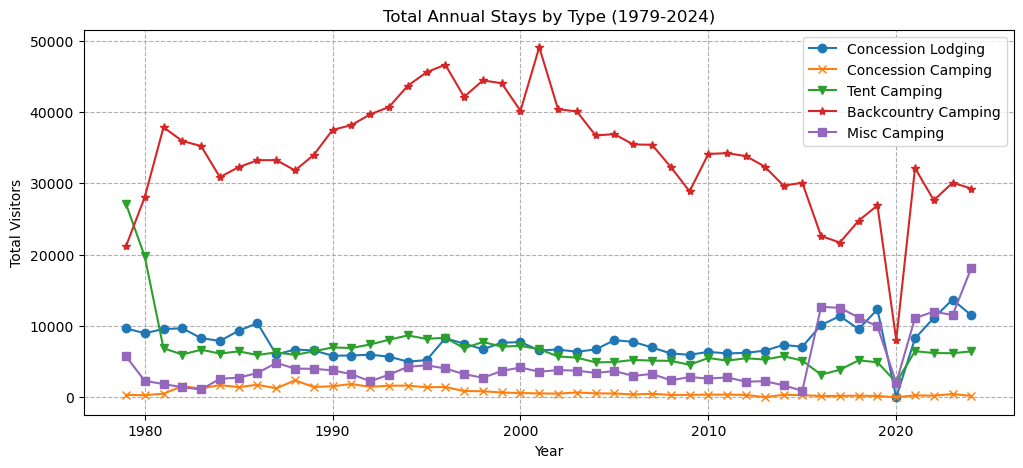

In [24]:
plt.figure(figsize = (12, 5))

plt.plot(con_lodge['Year'], con_lodge['Annual Total'], marker = 'o')
plt.plot(con_camp['Year'], con_camp['Annual Total'], marker = 'x')
plt.plot(tent_camp['Year'], tent_camp['Annual Total'], marker = 'v')
plt.plot(back_camp['Year'], back_camp['Annual Total'], marker = '*')
plt.plot(misc_camp['Year'], misc_camp['Annual Total'], marker = 's')

plt.title('Total Annual Stays by Type (1979-2024)')
plt.xlabel('Year')
plt.ylabel('Total Visitors')
plt.grid(True, linestyle = '--')
plt.legend(["Concession Lodging", "Concession Camping", "Tent Camping", "Backcountry Camping", "Misc Camping"], loc = "upper right")
plt.show()

The above graph illustrates total annual stays by each stay type. Backcountry camping was by far the 
most popular type of stay consistently from 1979 through 2024. Interestingly, tent camping was initially the most prevalent type of camping, but sharply fell and became comparable to all other camping types with the exception of backcountry camping. Concession lodging and miscellaneous camping saw a decline in prevalence but then increased beginning around 2015 and has slowly continued to grow (with the exception of 2020). Concession camping has remained constistently low from 1979 through 2024. 

### Annual Concession vs. Non-Concession Stays

In [25]:
# Merge relevant tables for comparison

# Set new column names for easier comparison when in tables
con_lodge.columns = ['Year', 'Con_Lodge Min', 'Con_Lodge Avg', 'Con_Lodge Max', 'Con_Lodge Total']
con_camp.columns = ['Year', 'Con_Camping Min', 'Con_Camping Avg', 'Con_Camping Max', 'Con_Camping Total']
tent_camp.columns = ['Year', 'Tent_Camping Min', 'Tent_Camping Avg', 'Tent_Camping Max', 'Tent_Camping Total']
back_camp.columns = ['Year', 'Back_Country_Camping Min', 'Back_Country_Camping Avg', 'Back_Country_Camping Max', 'Back_Country_Camping Total']
misc_camp.columns = ['Year', 'Misc_Camping Min', 'Misc_Camping Avg', 'Misc_Camping Max', 'Misc_Camping Total']

# Merge concession tables
con_stays = pd.merge(con_lodge, con_camp, on = 'Year').sort_values(by = 'Year').reset_index(inplace = False)
con_stays = con_stays.drop('index', axis = 1)

# Merge non-concession, non-misc camping now to be used later
non_misc_camp_stays = pd.merge(tent_camp, back_camp, on = 'Year').sort_values(by = 'Year').reset_index(inplace = False)
non_misc_camp_stays = non_misc_camp_stays.drop('index', axis = 1)                 

# Merge all non-concession camping
non_con_camp_stays = pd.merge(non_misc_camp_stays, misc_camp, on = 'Year').sort_values(by = 'Year')

# Print tables on concession and non-concession stays by annual total. Use tail to show most recent years
print('Concession Stays by Annual Total:')
print(con_stays.tail(5))
print('Non-concession Stays by Annual Total:')
print(non_con_camp_stays.tail(5))

Concession Stays by Annual Total:
    Year  Con_Lodge Min  Con_Lodge Avg  Con_Lodge Max  Con_Lodge Total  \
41  2020              0       0.000000              0                0   
42  2021              0    1178.428571           2757             8249   
43  2022              0    1588.428571           4175            11119   
44  2023              0    1957.000000           4895            13699   
45  2024              0    1638.285714           4376            11468   

    Con_Camping Min  Con_Camping Avg  Con_Camping Max  Con_Camping Total  
41                0         0.000000                0                  0  
42                0        36.857143              144                258  
43                0        31.000000               96                217  
44                0        63.571429              196                445  
45                0        27.571429               88                193  
Non-concession Stays by Annual Total:
    Year  Tent_Camping Min  Tent_

In [26]:
#Add visualization(s) comparing con_stays and non_con_camp_stays

### Indoor Lodging vs. Outdoor Camping Stays

In [27]:
# Merge all camping tables for comparison to lodging
# Miscellaneous is excluded as it includes some options for indoor camping

all_outdoor_camp = pd.merge(con_camp, non_misc_camp_stays, on = 'Year').sort_values(by = 'Year').reset_index(inplace = False)
all_outdoor_camp = all_outdoor_camp.drop('index', axis = 1)

# Print tables on indoor and outdoor stays by annual total. Use tail to show most recent years
print('Indoor Stays by Annual Total:')
print(con_lodge.tail(5))
print('Outdoor Stays by Annual Total:')
print(all_outdoor_camp.tail(5))

Indoor Stays by Annual Total:
    Year  Con_Lodge Min  Con_Lodge Avg  Con_Lodge Max  Con_Lodge Total
41  2020              0       0.000000              0                0
42  2021              0    1178.428571           2757             8249
43  2022              0    1588.428571           4175            11119
44  2023              0    1957.000000           4895            13699
45  2024              0    1638.285714           4376            11468
Outdoor Stays by Annual Total:
    Year  Con_Camping Min  Con_Camping Avg  Con_Camping Max  \
41  2020                0         0.000000                0   
42  2021                0        36.857143              144   
43  2022                0        31.000000               96   
44  2023                0        63.571429              196   
45  2024                0        27.571429               88   

    Con_Camping Total  Tent_Camping Min  Tent_Camping Avg  Tent_Camping Max  \
41                  0                 0        298.0000

In [28]:
# Add visualization(s) comparing indoor and outdoor stays

# Regresison (If Time)